In [1]:
# FASE 2 ADQUISICIÓN (Datlas)
import pandas as pd, numpy as np, os, glob

csv = next((p for p in ["ejercicio_fases_analitica_farmacia.csv"]
+ glob.glob("**/ejercicio_fases_analitica_farmacia.csv", recursive=True)
if os.path.exists(p)), None)

if csv:
    df = pd.read_csv(csv)
else:
    raise FileNotFoundError("Sube 'ejercicio_fases_analitica_farmacia.csv' al panel izquierdo.")

inventario = pd.DataFrame([
    ["semana", "int", "ERP ventas","completo", "Analítica"],
    ["fecha_semana", "fecha", "ERP", "validez fechas","Analítica"],
    ["producto", "str", "Maestro de productos","sin nulos", "Compras"],
    ["stock_inicio_sem", "int", "ERP inventario","nulos<1%", "Operaciones"],
    ["unidades_vendidas", "int", "ERP ventas","ok", "Ventas"],
    ["stock_fin_sem", "int", "ERP inventario", "ok", "Operaciones"],
    ["stockout_sem","0/1", "ERP","ok", "Operaciones"],
    ["lead_time_dias","int", "Compras","ok","Compras"],
], columns=["campo","tipo", "fuente", "calidad", "responsable"])

inventario

,campo,tipo,fuente,calidad,responsable
0,semana,int,ERP ventas,completo,Analítica
1,fecha_semana,fecha,ERP,validez fechas,Analítica
2,producto,str,Maestro de productos,sin nulos,Compras
3,stock_inicio_sem,int,ERP inventario,nulos<1%,Operaciones
4,unidades_vendidas,int,ERP ventas,ok,Ventas
5,stock_fin_sem,int,ERP inventario,ok,Operaciones
6,stockout_sem,0/1,ERP,ok,Operaciones
7,lead_time_dias,int,Compras,ok,Compras


In [2]:
# FASE 3 - PREPARACIÓN (Datlas)
df["fecha_semana"] = pd.to_datetime(df["fecha_semana"], errors="coerce")
df["semana"] = df["semana"].astype (int)
df["tasa_venta"] = (df["unidades_vendidas"] / df["stock_inicio_sem"]).clip (0,1).fillna (0)

bitacora = [
    "Convertí 'fecha_semana' a datetime.",
    "Aseguré 'semana' como entero.",
    "Creé 'tasa_venta' = vendidas/stock_inicio (0..1) у reemplacé nulos por 0."
]

diccionario = pd.DataFrame({
    "campo":["tasa_venta"],
    "definicion":["Razón de rotación semanal del producto (vendidas/stock_inicio)."],
    "dominio":["0..1"], 
    "nota_calidad": ["clip y fillna aplicados"]
})

diccionario

,campo,definicion,dominio,nota_calidad
0,tasa_venta,Razón de rotación semanal del producto (vendid...,0..1,clip y fillna aplicados


,% faltante
producto,
Ibuprofeno_400mg,3.8
Paracetamol_500mg,3.8
Alcohol_Gel,0.0
Antiacido,0.0
Antigripal,0.0
Antihistaminico,0.0
Bloqueador_Solar,0.0
Jarabe_Tos,0.0
Probiotico,0.0


,unidades
semana,
22,184
23,222
24,168
25,188
26,195


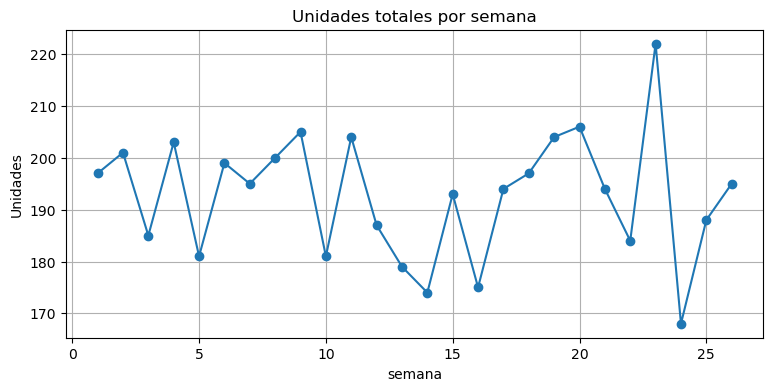

In [3]:
# FASE 4 - EXPLORACIÓN (Datlas)
top_faltante = (df.groupby("producto") ["stockout_sem"]
.mean().mul(100).round(1)
.sort_values(ascending=False).head (10)).to_frame(name="% faltante")

display(top_faltante)

serie_total = df.groupby("semana") ["unidades_vendidas"].sum()
display(serie_total.tail().to_frame (name="unidades"))

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] =(9,4);
plt.rcParams["axes.grid"]=True
serie_total.plot(marker="o"); plt.title("Unidades totales por semana"); plt.ylabel("Unidades"); plt.show()

In [4]:
#FASE 5-MODELADO (Datlas) tendencia lineal
import numpy as np
serie = serie_total.reset_index()
X = serie ["semana"].to_numpy().reshape(-1,1)
y = serie ["unidades_vendidas"].to_numpy()
Xd = np.hstack([X, np.ones_like(X)])
a,b = (np.linalg.pinv(Xd.T@Xd)@(Xd.T@y)).tolist()
next_week = int(serie ["semana"].max()+1)
y_next = a*next_week + b
print (f"Pronóstico total para semana {next_week}: {y_next:.1f}")

Pronóstico total para semana 27: 191.4


In [5]:
# FASE 6 - EVALUACIÓN Y COMUNICACIÓN (Datlas)
kpi_baseline = df["stockout_sem"].mean()*100
resumen = f"""
KPI base: {kpi_baseline:.1f}% de semanas con faltante.
Pronóstico próximo período (unidades totales): {y_next:.1f}.
Decisión propuesta: aplicar reglas de reorden a productos críticos (ver Fase 7) para reducir ≥20% faltantes.
Riesgos: variabilidad estacional y lead time.
Siguiente paso: monitoreo semanal y recalibración de umbrales.
"""
print(resumen.strip())

KPI base: 0.6% de semanas con faltante.
Pronóstico próximo período (unidades totales): 191.4.
Decisión propuesta: aplicar reglas de reorden a productos críticos (ver Fase 7) para reducir ≥20% faltantes.
Riesgos: variabilidad estacional y lead time.
Siguiente paso: monitoreo semanal y recalibración de umbrales.


In [6]:
# FASE 7 IMPLEMENTACIÓN (Datlas) reglas prescriptivas
# pronóstico por producto (media 3 semanas) -> cobertura
agg = df.groupby(["producto","semana"], as_index=False) ["unidades_vendidas"].sum()
hist3 = (agg.sort_values(["producto","semana"]).groupby("producto", group_keys=False).tail(3))
prom3 = (hist3.groupby("producto", as_index=False) ["unidades_vendidas"]
.mean().rename (columns={"unidades_vendidas":"forecast_next"}))

base = df[df["semana"]==df["semana"].max()].copy().merge (prom3, on="producto", how="left")
base ["forecast_next"] = base ["forecast_next"].fillna (base ["unidades_vendidas"]).clip(lower=1)
base ["cobertura_sem"] = (base ["stock_fin_sem"]/base ["forecast_next"]).replace([np.inf,-np.inf], np.nan).fillna (999.0)

UMBRAL_COB = 1.2
UMBRAL_LT = 5
base ["alerta_reorden"] = ((base ["cobertura_sem"] < UMBRAL_COB) & (base ["lead_time_dias"] >= UMBRAL_LT)).astype(int)

reorden = base.loc [base ["alerta_reorden"] == 1, 
["producto","stock_fin_sem","forecast_next","cobertura_sem","lead_time_dias"]]

reorden.to_csv("Reorden_semana_actual.csv", index=False)
print("Generado: Reorden_semana_actual.csv")
reorden.head(10)

Generado: Reorden_semana_actual.csv


,producto,stock_fin_sem,forecast_next,cobertura_sem,lead_time_dias
1,Ibuprofeno_400mg,32,29.0,1.103448,5


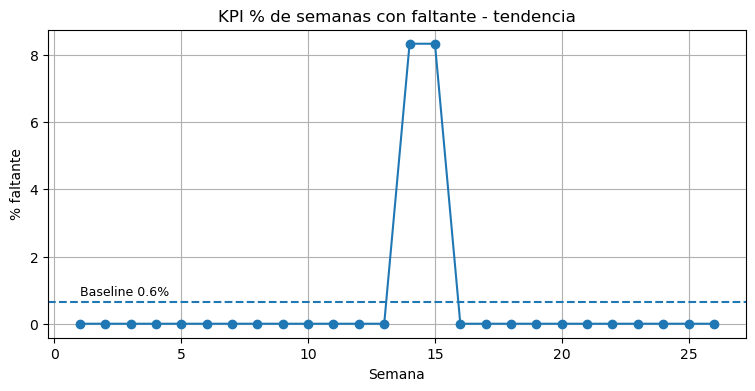

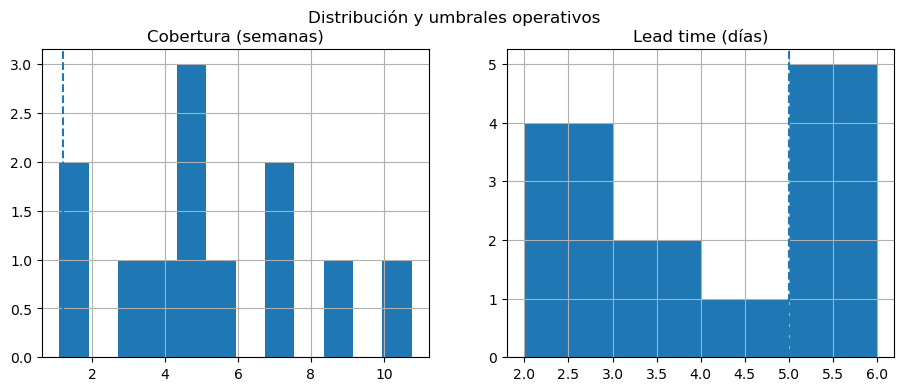

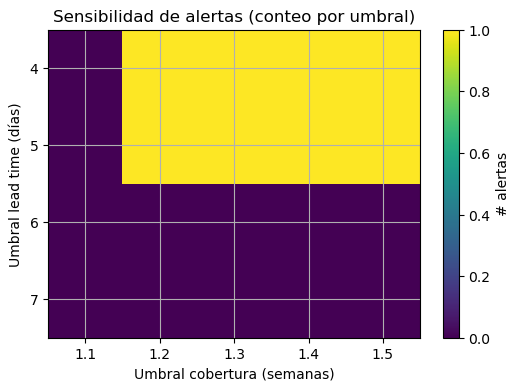

In [7]:
#=== FASE 8 Tablero ejecutivo (gráficos) ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# (A) Reconstrucción mínima si no existe 'base'
if "base" not in globals():
    agg = df.groupby(["producto", "semana"], as_index=False) ["unidades_vendidas"].sum()
    hist3 = (agg.sort_values(["producto","semana"]).groupby("producto", group_keys=False).tail(3))
    prom3 = (hist3.groupby("producto", as_index=False) ["unidades_vendidas"].mean().rename(columns={"unidades_vendidas":"forecast_next"}))
    base = (df[df["semana"]==df["semana"].max()].copy().merge(prom3, on="producto", how="left"))
    base["forecast_next"] = base["forecast_next"].fillna(base["unidades_vendidas"]).clip(lower=1)
    base["cobertura_sem"] = (base["stock_fin_sem"]/base["forecast_next"]).replace([np.inf,-np.inf], np.nan).fillna (999.0)
    if "tasa_venta" not in base.columns:
        base["tasa_venta"] = (base["unidades_vendidas"]/base["stock_inicio_sem"]).clip (0,1).fillna(0)

# Umbrales actuales (ajústalos)
COB = 1.2 # cobertura mínima aceptable en semanas
LT = 5 # lead time mínimo para disparar (días)

# (B) KPIs ejecutivos
kpi_sem = df.groupby("semana") ["stockout_sem"].mean()*100
kpi_baseline = kpi_sem.mean()

# Alertas actuales
alertas_mask = (base["cobertura_sem"] < COB) & (base["lead_time_dias"] >= LT)
n_alertas = int(alertas_mask.sum())
productos_alerta = base.loc[alertas_mask, "producto"].tolist()

# (C) Gráfico 1: KPI faltante (tendencia)
plt.figure()
kpi_sem.plot(marker="o")
plt.axhline(kpi_baseline, linestyle="--")
plt.title("KPI % de semanas con faltante - tendencia")
plt.ylabel("% faltante"); plt.xlabel("Semana")
plt.text(kpi_sem.index.min(), kpi_baseline + 0.2, f"Baseline {kpi_baseline:.1f}%", fontsize=9)
plt.show()

# (D) Gráfico 2: Distribuciones con umbrales
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].hist(base["cobertura_sem"], bins=12)
ax[0].axvline(COB, linestyle="--")
ax[0].set_title("Cobertura (semanas)")
ax[1].hist(base["lead_time_dias"], bins=range(int(base["lead_time_dias"].min()), int(base["lead_time_dias"].max())+1))
ax[1].axvline(LT, linestyle="--")
ax[1].set_title("Lead time (días)")
plt.suptitle("Distribución y umbrales operativos")
plt.show()

# (E) Gráfico 3: Sensibilidad (heatmap)
cobs = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
lts = np.array([4, 5, 6, 7])
M = np.zeros((len(lts), len(cobs)), dtype=int)
for i, lt_ in enumerate(lts):
    for j, cb in enumerate(cobs):
        M[i,j] = int(((base["cobertura_sem"] < cb) & (base["lead_time_dias"] >= lt_)).sum())

plt.figure(figsize=(6,4))
plt.imshow(M, aspect="auto")
plt.colorbar(label="# alertas")
plt.xticks(range(len(cobs)), cobs); plt.yticks(range(len(lts)), lts)
plt.xlabel("Umbral cobertura (semanas)"); plt.ylabel("Umbral lead time (días)")
plt.title("Sensibilidad de alertas (conteo por umbral)")
plt.show()